# 서울 출퇴근 스트레스 EDA
**데이터**: `monthly_scores_문헌기반_서울_renorm.csv` (2022~2024, 서울 25개 자치구, 분기 대표월)

| 분석 단계 | 내용 |
|-----------|------|
| 1. 기초 통계 | describe / 결측 / 상관 히트맵 |
| 2. 상관관계 | Pearson·Spearman + 산점도 |
| 3. 분기별 차이 | 박스플롯 + ANOVA |
| 4. 자치구별 패턴 | 히트맵 + KMeans 클러스터 |
| 5. 시계열 추세 | 라인차트 + 연도별 변화율 |
| 6. 변수 영향력 | 회귀분석 + RandomForest |
| 7. 차이 기반 분석 | 전분기 증감률 + 상관 |

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, pearsonr, spearmanr
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

from pathlib import Path
import os

def _find_root():
    """프로젝트 루트(.git 포함 디렉터리)를 자동 탐색."""
    p = Path(os.getcwd()).resolve()
    for x in [p] + list(p.parents):
        if (x / '.git').exists():
            return x
    return p

ROOT = _find_root()
# 데이터 위치: ROOT/KM/traffic/commute/data/
DATA = ROOT / 'KM' / 'traffic' / 'commute' / 'data' / 'monthly_scores_문헌기반_서울_renorm.csv'

raw = pd.read_csv(DATA, encoding='utf-8-sig')

# 분기 매핑
Q_MAP = {1: '1분기', 2:'1분기', 5: '2분기', 8: '3분기', 11: '4분기'}
raw['분기'] = raw['월'].map(Q_MAP)
raw['연월'] = raw['연도'].astype(str) + '-' + raw['월'].astype(str).str.zfill(2)

# 자치구·연월 단위로 집계 (원본파일 여러 개 → 평균)
AGG = {'총이동인구수': 'mean', '평균이동시간': 'mean', '총이동시간': 'mean',
       '유입인구_norm': 'mean', '평균이동시간_norm': 'mean', '총이동시간_norm': 'mean',
       '출퇴근스트레스점수': 'mean'}
df = raw.groupby(['연도', '월', '분기', '연월', '자치구명'], as_index=False).agg(AGG)

VARS  = ['총이동인구수', '평균이동시간', '총이동시간']
SCORE = '출퇴근스트레스점수'

print(f'집계 후: {len(df)}행  |  자치구: {df["자치구명"].nunique()}개  |  연월: {df["연월"].nunique()}개')
df.head(3)

집계 후: 300행  |  자치구: 25개  |  연월: 12개


,연도,월,분기,연월,자치구명,총이동인구수,평균이동시간,총이동시간,유입인구_norm,평균이동시간_norm,총이동시간_norm,출퇴근스트레스점수
0,2022,1,1분기,2022-01,강남구,556713.94,44.413550,2.472564e+07,0.984099,0.260583,0.967871,72.762264
1,2022,1,1분기,2022-01,강동구,355181.83,42.506794,1.509764e+07,0.508091,0.146904,0.468048,37.366682
2,2022,1,1분기,2022-01,강북구,221881.60,43.444795,9.639601e+06,0.193243,0.202827,0.184703,19.488922


---
## 1. 기초 통계
전체 데이터의 분포와 결측 여부를 먼저 확인한다.

In [3]:
print('=== 기술통계 ==='); display(df[VARS + [SCORE]].describe().round(2))
print('\n=== 결측치 ==='); print(df.isnull().sum())

=== 기술통계 ===


,총이동인구수,평균이동시간,총이동시간,출퇴근스트레스점수
count,300.00,300.00,300.00,300.00
mean,553126.37,53.51,29903228.25,29.75
std,220387.76,4.25,12966786.99,13.06
min,140066.40,40.04,6081701.45,7.05
25%,435698.56,51.82,23042207.68,22.19
50%,509417.84,53.50,27752961.82,26.30
75%,641116.49,55.49,33993081.20,34.99
max,1316421.06,64.70,77411567.52,75.31



=== 결측치 ===
연도             0
월              0
분기             0
연월             0
자치구명           0
총이동인구수         0
평균이동시간         0
총이동시간          0
유입인구_norm      0
평균이동시간_norm    0
총이동시간_norm     0
출퇴근스트레스점수      0
dtype: int64


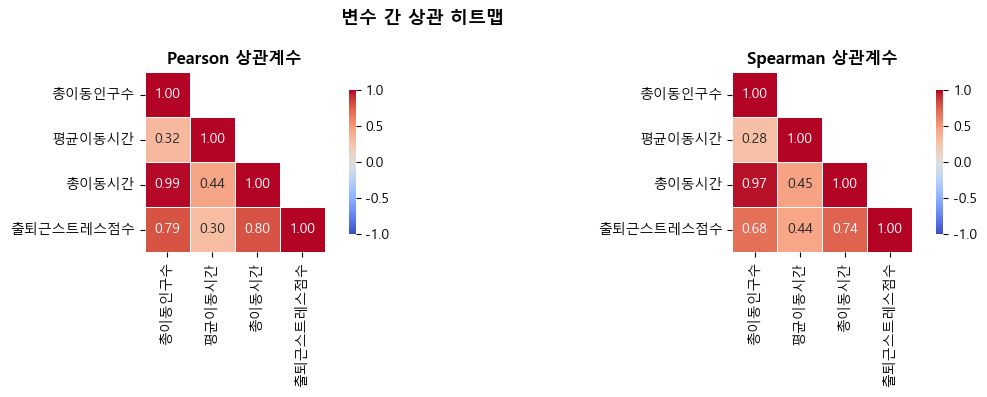

In [4]:
# 변수 간 상관 히트맵
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, method in zip(axes, ['pearson', 'spearman']):
    corr = df[VARS + [SCORE]].corr(method=method)
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # 대각선 위쪽만 마스킹
    sns.heatmap(corr, ax=ax, annot=True, fmt='.2f', cmap='coolwarm',
                vmin=-1, vmax=1, mask=mask, square=True,
                linewidths=0.5, cbar_kws={'shrink': 0.8})
    ax.set_title(f'{method.capitalize()} 상관계수', fontweight='bold')

plt.suptitle('변수 간 상관 히트맵', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 상관구조 해석

총이동인구수와 총이동시간은 매우 높은 상관관계를 보였다(Pearson ≈ 0.99, Spearman ≈ 0.97). 
이는 총이동시간이 이동인구 규모의 영향을 강하게 받는 변수임을 시사한다.

반면 평균이동시간과 총이동시간의 상관은 약 0.44 수준으로, 
두 변수는 서로 다른 정보 축을 일부 반영한다.

| 변수 | 반영하는 차원 |
|------|---------------|
| 총이동인구수 | 혼잡 및 이동 규모 |
| 평균이동시간 | 개인 체감 이동 부담 |
| 총이동시간 | 도시 전체 이동 부담(burden) |

> **주의**: 총이동인구수 ↔ 총이동시간의 높은 상관은 다중공선성 가능성을 시사하므로 이후 VIF 분석에서 검정한다.

---
## 2. 스트레스 점수 ↔ 구성변수 상관관계

세 가지 구성변수(총이동인구수, 평균이동시간, 총이동시간)가 스트레스 점수와
어떤 관계를 가지는지 수치·시각적으로 확인한다.

- **Pearson**: 선형 상관 강도
- **Spearman**: 순위 기반 단조 상관 (이상치에 강건)
- **산점도 + 회귀선**: 관계의 방향과 분산 시각화

In [5]:
# Pearson / Spearman 수치 비교
rows = []
for v in VARS:
    pr, pp = pearsonr(df[v], df[SCORE])
    sr, sp = spearmanr(df[v], df[SCORE])
    rows.append({'변수': v,
                 'Pearson_r': round(pr, 3), 'Pearson_p': round(pp, 4),
                 'Spearman_r': round(sr, 3), 'Spearman_p': round(sp, 4)})

corr_tbl = pd.DataFrame(rows).set_index('변수')
display(corr_tbl)
print('\n* p < 0.05: 통계적으로 유의한 상관')

,Pearson_r,Pearson_p,Spearman_r,Spearman_p
변수,,,,
총이동인구수,0.792,0.0,0.684,0.0
평균이동시간,0.303,0.0,0.435,0.0
총이동시간,0.803,0.0,0.737,0.0



* p < 0.05: 통계적으로 유의한 상관


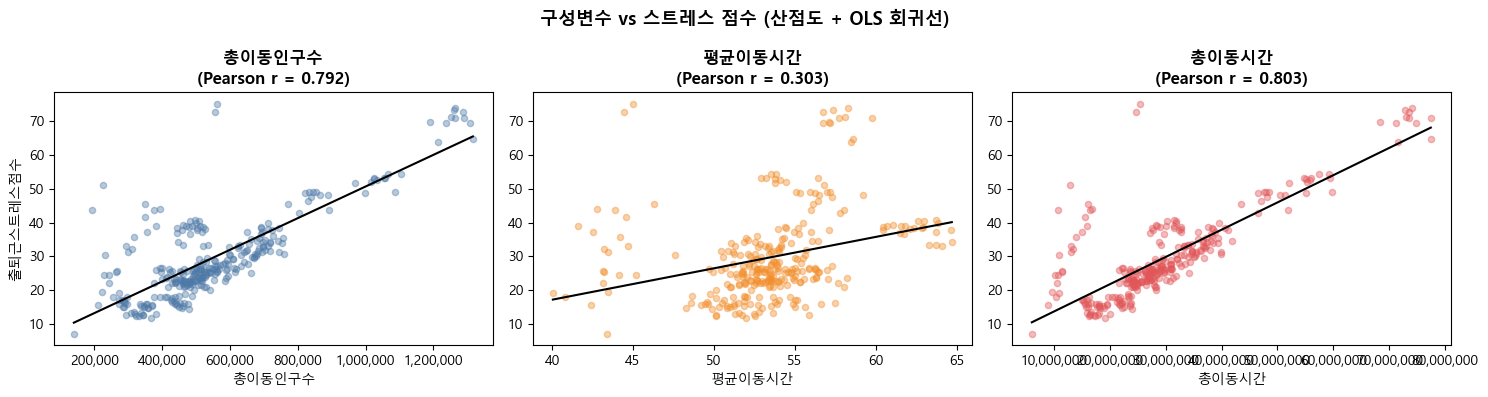

In [6]:
# 산점도 + 회귀선
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['#4e79a7', '#f28e2b', '#e15759']

for ax, v, c in zip(axes, VARS, colors):
    ax.scatter(df[v], df[SCORE], alpha=0.4, s=20, color=c)
    m, b = np.polyfit(df[v], df[SCORE], 1)
    xline = np.linspace(df[v].min(), df[v].max(), 100)
    ax.plot(xline, m * xline + b, color='black', linewidth=1.5)
    pr, _ = pearsonr(df[v], df[SCORE])
    ax.set_title(f'{v}\n(Pearson r = {pr:.3f})', fontweight='bold')
    ax.set_xlabel(v)
    ax.set_ylabel(SCORE if ax == axes[0] else '')
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('구성변수 vs 스트레스 점수 (산점도 + OLS 회귀선)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 스트레스 점수와 구성변수 관계

출퇴근 스트레스 점수는 총이동인구수·총이동시간과 높은 양의 상관관계를 보였다. 
이동 규모 및 혼잡 수준이 자치구 단위 스트레스에 중요한 영향을 미칠 가능성을 시사한다.

반면 평균이동시간은 상대적으로 중간 수준의 상관을 보였으며, 
도시 집계 단위에서 개인 체감 이동시간보다 전체 이동량 효과가 더 크게 반영될 수 있음을 의미한다.

---
## 3. 분기별 스트레스 차이 분석

분기(계절)에 따라 출퇴근 스트레스에 유의미한 차이가 있는지 검정한다.

- **귀무가설 H₀**: 분기별 스트레스 평균이 모두 동일하다
- **대립가설 H₁**: 적어도 하나의 분기는 다르다
- **ANOVA**: 집단 간 분산 비교 (F-검정)
- **Tukey HSD**: ANOVA 유의 시 어떤 분기끼리 다른지 사후 검정

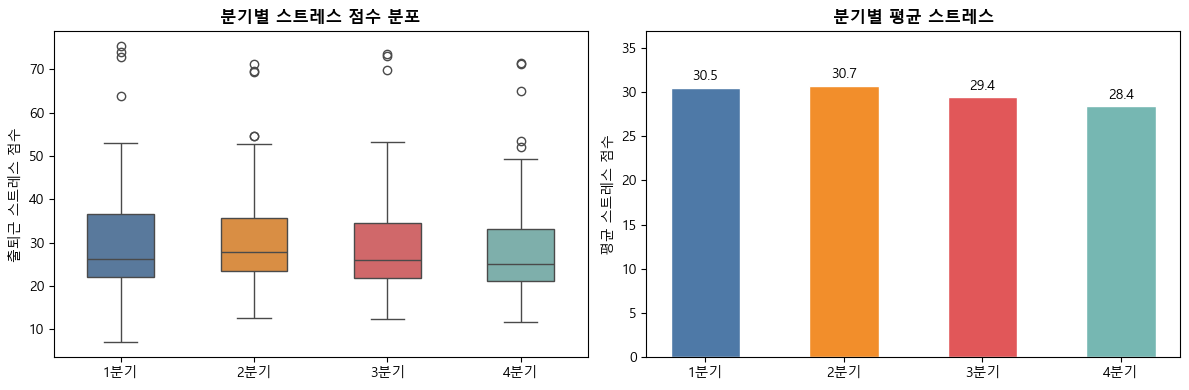

In [7]:
q_order = ['1분기', '2분기', '3분기', '4분기']
groups  = [df[df['분기'] == q][SCORE].values for q in q_order]

# 박스플롯
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

palette = {'1분기': '#4e79a7', '2분기': '#f28e2b', '3분기': '#e15759', '4분기': '#76b7b2'}
sns.boxplot(data=df, x='분기', y=SCORE, order=q_order,
            palette=palette, ax=axes[0], width=0.5)
axes[0].set_title('분기별 스트레스 점수 분포', fontweight='bold')
axes[0].set_xlabel(''); axes[0].set_ylabel('출퇴근 스트레스 점수')

means = df.groupby('분기')[SCORE].mean().reindex(q_order)
bars = axes[1].bar(q_order, means.values, color=[palette[q] for q in q_order], width=0.5, edgecolor='white')
axes[1].bar_label(bars, fmt='%.1f', padding=3, fontsize=10)
axes[1].set_title('분기별 평균 스트레스', fontweight='bold')
axes[1].set_ylabel('평균 스트레스 점수')
axes[1].set_ylim(0, means.max() * 1.2)

plt.tight_layout(); plt.show()

In [8]:
# ANOVA
F, p = f_oneway(*groups)
print(f'=== One-way ANOVA ===')
print(f'F = {F:.4f},  p = {p:.4f}')
print(f'결론: {"H₀ 기각 — 분기 간 유의한 차이 있음" if p < 0.05 else "H₀ 채택 — 분기 간 유의한 차이 없음"} (α=0.05)')

if p < 0.05:
    print('\n=== Tukey HSD 사후 검정 ===')
    tukey = pairwise_tukeyhsd(df[SCORE], df['분기'], alpha=0.05)
    print(tukey)

=== One-way ANOVA ===
F = 0.5154,  p = 0.6720
결론: H₀ 채택 — 분기 간 유의한 차이 없음 (α=0.05)


---
## 4. 자치구별 패턴 분석

자치구별 평균 스트레스와 구성변수를 비교하고,
KMeans 클러스터링으로 유사한 통근 패턴을 가진 자치구 그룹을 식별한다.

예상 군집:
- **고인구·고스트레스형**: 강남·송파 등 유동인구 집중 지역
- **장거리 통근형**: 이동시간이 길고 총이동시간 큰 지역
- **저스트레스형**: 외곽, 상대적으로 혼잡 낮음

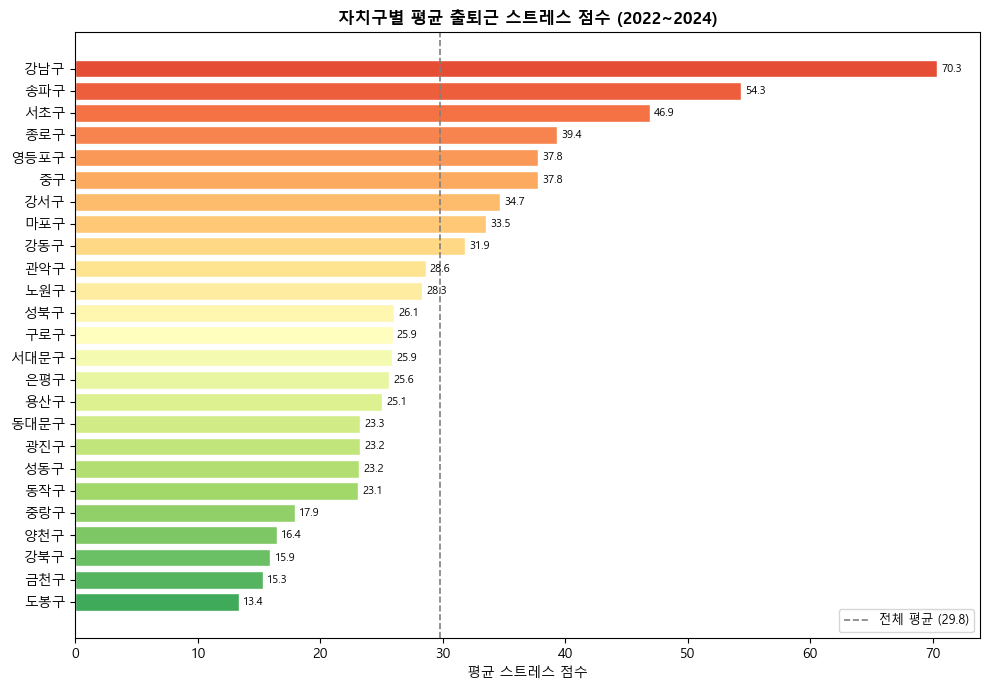

In [9]:
# 자치구별 평균
gu_avg = df.groupby('자치구명')[VARS + [SCORE]].mean().round(2)
gu_avg = gu_avg.sort_values(SCORE, ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(gu_avg.index, gu_avg[SCORE],
               color=plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(gu_avg))),
               edgecolor='white')
ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=8)
ax.set_title('자치구별 평균 출퇴근 스트레스 점수 (2022~2024)', fontweight='bold')
ax.set_xlabel('평균 스트레스 점수')
ax.axvline(gu_avg[SCORE].mean(), color='gray', linestyle='--', linewidth=1.2, label=f'전체 평균 ({gu_avg[SCORE].mean():.1f})')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

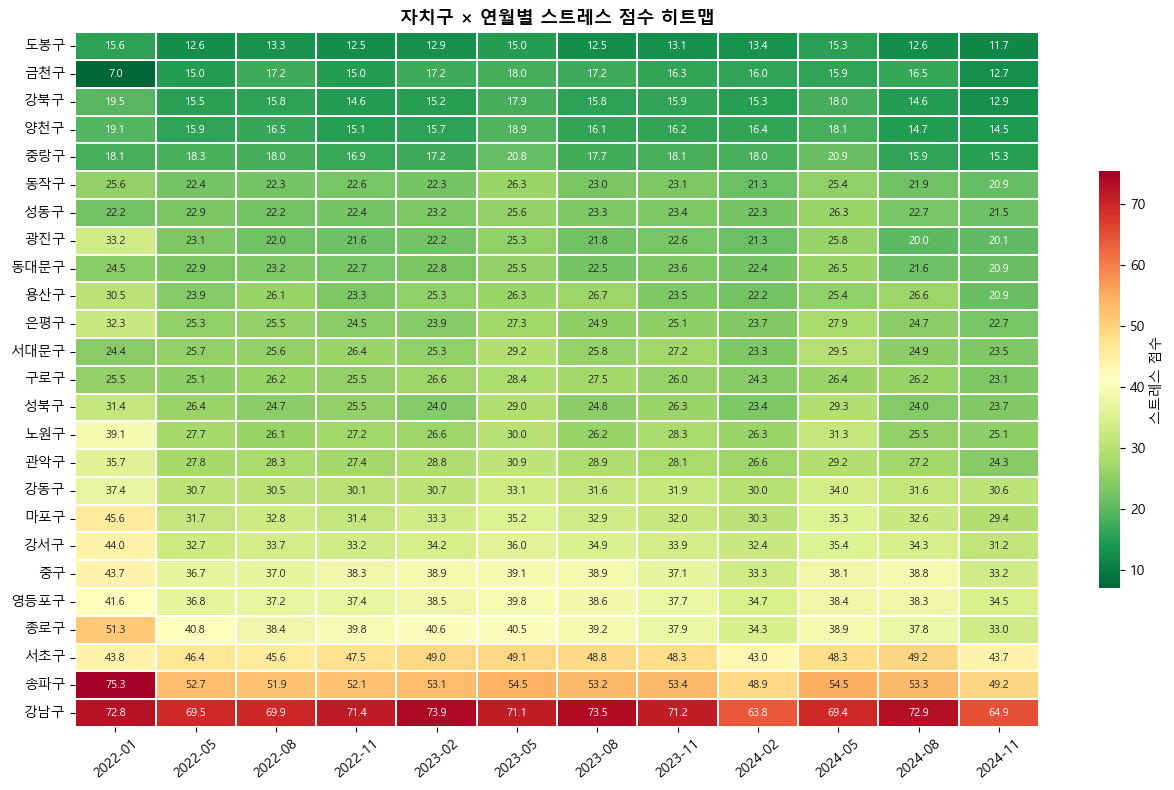

In [10]:
# 자치구 × 연월 스트레스 히트맵
pivot = df.pivot_table(index='자치구명', columns='연월', values=SCORE)
pivot = pivot.loc[gu_avg.index]  # 평균 스트레스 오름차순 정렬

fig, ax = plt.subplots(figsize=(13, 8))
sns.heatmap(pivot, ax=ax, cmap='RdYlGn_r', annot=True, fmt='.1f',
            linewidths=0.3, annot_kws={'size': 8},
            cbar_kws={'label': '스트레스 점수', 'shrink': 0.6})
ax.set_title('자치구 × 연월별 스트레스 점수 히트맵', fontsize=13, fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('')
ax.tick_params(axis='x', rotation=40)
plt.tight_layout(); plt.show()

=== 클러스터별 평균 ===


,총이동인구수,평균이동시간,총이동시간,출퇴근스트레스점수
클러스터,,,,
0,466005.7,62.1,29000342.9,38.6
1,1001735.5,55.4,56181665.4,57.2
2,494547.1,52.4,26051751.2,24.8


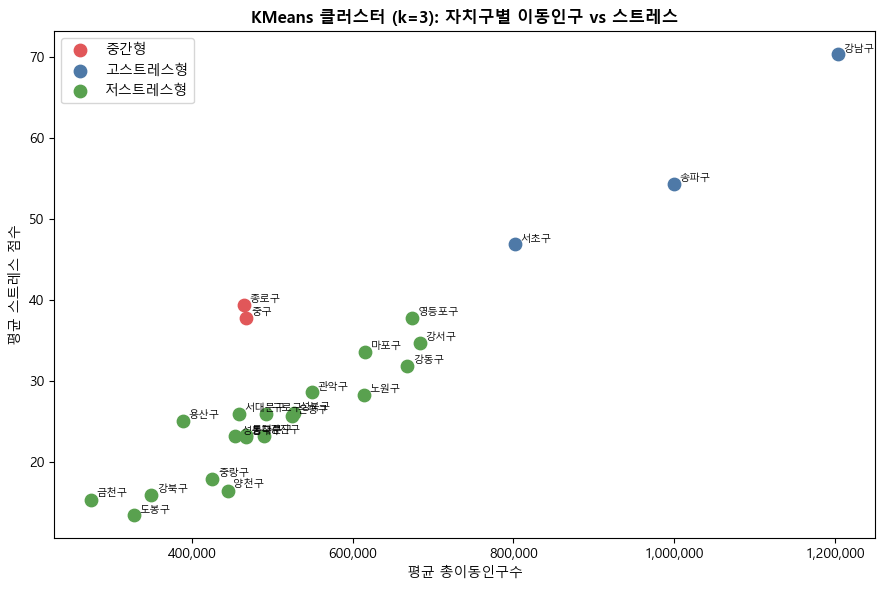

In [11]:
# KMeans 클러스터링 (k=3)
X = gu_avg[VARS + [SCORE]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

km = KMeans(n_clusters=3, random_state=42, n_init=10)
gu_avg['클러스터'] = km.fit_predict(X_scaled)

# 클러스터 특성 요약
print('=== 클러스터별 평균 ===');
display(gu_avg.groupby('클러스터').mean().round(1))

# 시각화: 총이동인구수 vs 출퇴근스트레스, 클러스터별 색
colors_c = {0: '#e15759', 1: '#4e79a7', 2: '#59a14f'}
labels_c = {}
cluster_means = gu_avg.groupby('클러스터')[SCORE].mean().sort_values(ascending=False)
label_names = ['고스트레스형', '중간형', '저스트레스형']
for rank, (c, _) in enumerate(cluster_means.items()):
    labels_c[c] = label_names[rank]

fig, ax = plt.subplots(figsize=(9, 6))
for c, grp in gu_avg.groupby('클러스터'):
    ax.scatter(grp['총이동인구수'], grp[SCORE],
               color=colors_c[c], s=80, label=labels_c[c], zorder=3)
    for _, row in grp.iterrows():
        ax.annotate(row.name, (row['총이동인구수'], row[SCORE]),
                    fontsize=7.5, xytext=(4, 2), textcoords='offset points')

ax.set_xlabel('평균 총이동인구수'); ax.set_ylabel('평균 스트레스 점수')
ax.set_title('KMeans 클러스터 (k=3): 자치구별 이동인구 vs 스트레스', fontweight='bold')
ax.legend(); ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout(); plt.show()

In [12]:
# 군집별 특징 비교표
cluster_summary = gu_avg.groupby("클러스터").agg(
    자치구수=("클러스터", "count"),
    평균스트레스=(SCORE, "mean"),
    평균이동인구=("총이동인구수", "mean"),
    평균이동시간=("평균이동시간", "mean"),
).round(1)
cluster_summary.index = [labels_c[i] for i in cluster_summary.index]
cluster_summary.index.name = "군집 유형"
members = gu_avg.groupby("클러스터").apply(lambda g: ", ".join(g.index))
members.index = [labels_c[i] for i in members.index]
cluster_summary["자치구"] = members
display(cluster_summary)


,자치구수,평균스트레스,평균이동인구,평균이동시간,자치구
군집 유형,,,,,
중간형,2,38.6,466005.7,62.1,"중구, 종로구"
고스트레스형,3,57.2,1001735.5,55.4,"서초구, 송파구, 강남구"
저스트레스형,20,24.8,494547.1,52.4,"도봉구, 금천구, 강북구, 양천구, 중랑구, 동작구, 성동구, 광진구, 동대문구, ..."


### 자치구별 통근 패턴 특성

KMeans 클러스터링 결과, 서울 25개 자치구는 통근 부담의 원인에 따라 세 유형으로 구분되었다.

- **고혼잡형**: 대규모 유입인구에 의한 혼잡 기반 스트레스
- **장거리형**: 평균 이동시간이 길어 개인 체감 부담이 큰 스트레스
- **저부담형**: 이동량·시간 모두 상대적으로 낮은 지역

이는 정책 개입 방향이 자치구 유형마다 달라야 함을 시사한다.

---
## 5. 시계열 추세 분석

2022~2024년 동안 스트레스 점수가 어떻게 변화했는지,
자치구별 상승·하락 추세가 있는지 확인한다.

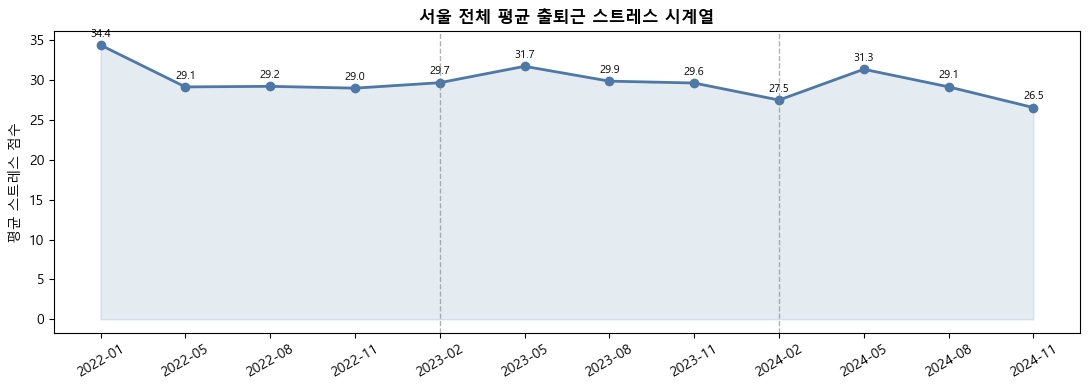

In [13]:
# 전체 평균 시계열
ts = df.groupby('연월')[SCORE].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(ts['연월'], ts[SCORE], marker='o', linewidth=2, color='#4e79a7')
ax.fill_between(ts['연월'], ts[SCORE], alpha=0.15, color='#4e79a7')

# 연도 구분선
for ym in ['2023-02', '2024-02']:
    if ym in ts['연월'].values:
        ax.axvline(ts[ts['연월'] == ym].index[0], color='gray', linestyle='--', linewidth=1, alpha=0.6)

for i, row in ts.iterrows():
    ax.annotate(f"{row[SCORE]:.1f}", (row['연월'], row[SCORE]),
                textcoords='offset points', xytext=(0, 6), fontsize=8, ha='center')

ax.set_title('서울 전체 평균 출퇴근 스트레스 시계열', fontweight='bold')
ax.set_ylabel('평균 스트레스 점수'); ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

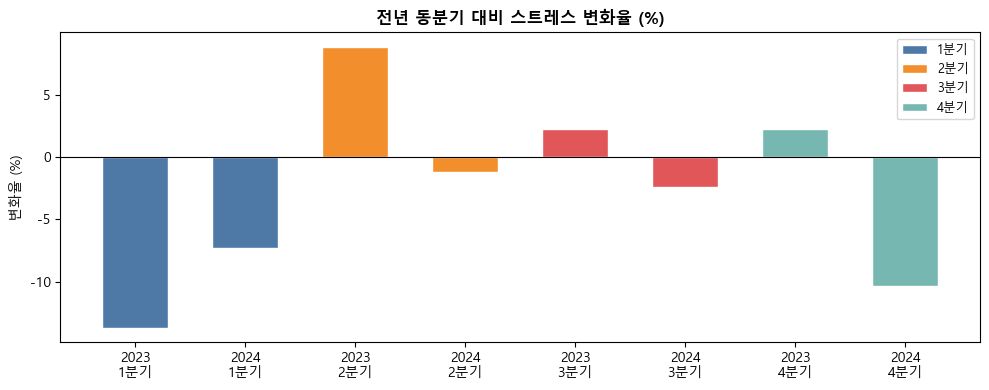

In [14]:
# 연도별 변화율 (전년 동분기 대비)
yr = df.groupby(['연도', '분기'])[SCORE].mean().reset_index()
yr = yr.sort_values(['분기', '연도'])
yr['전년대비변화율'] = yr.groupby('분기')[SCORE].pct_change() * 100

fig, ax = plt.subplots(figsize=(10, 4))
q_order = ['1분기', '2분기', '3분기', '4분기']
palette = {'1분기': '#4e79a7', '2분기': '#f28e2b', '3분기': '#e15759', '4분기': '#76b7b2'}

for q in q_order:
    sub = yr[(yr['분기'] == q) & yr['전년대비변화율'].notna()]
    ax.bar(sub['연도'].astype(str) + '\n' + q, sub['전년대비변화율'],
           color=palette[q], width=0.6, edgecolor='white', label=q)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('전년 동분기 대비 스트레스 변화율 (%)', fontweight='bold')
ax.set_ylabel('변화율 (%)'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

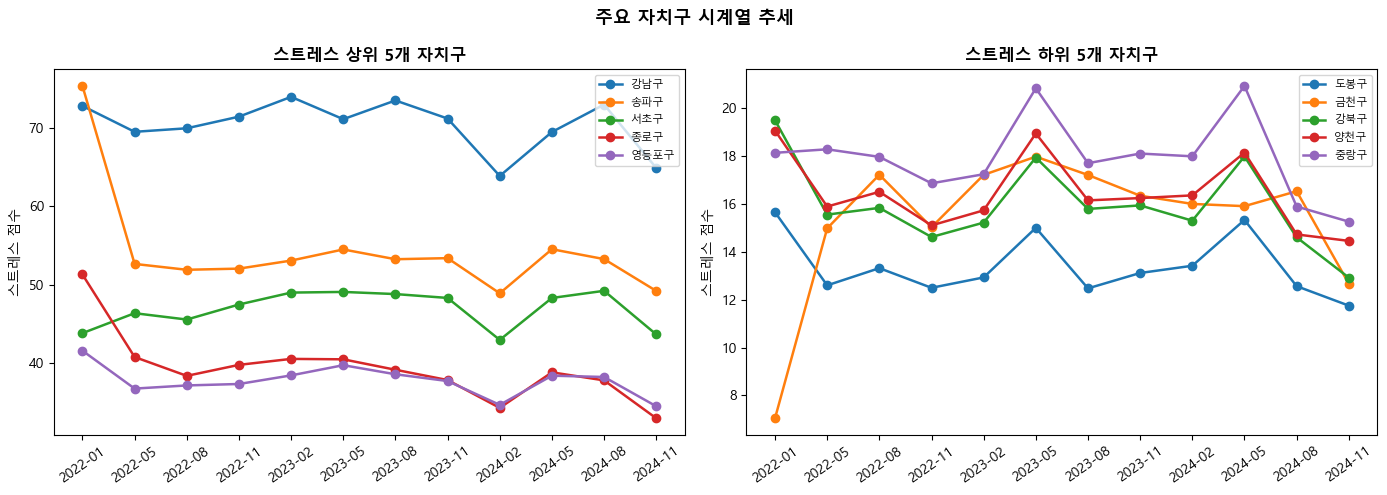

In [15]:
# 주요 자치구 시계열 비교 (상위 5 + 하위 5)
gu_mean = df.groupby('자치구명')[SCORE].mean()
top5  = gu_mean.nlargest(5).index.tolist()
bot5  = gu_mean.nsmallest(5).index.tolist()
target_gu = top5 + bot5

ts_gu = df[df['자치구명'].isin(target_gu)].groupby(['연월', '자치구명'])[SCORE].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for ax, title, gus in zip(axes,
                           ['스트레스 상위 5개 자치구', '스트레스 하위 5개 자치구'],
                           [top5, bot5]):
    for gu in gus:
        sub = ts_gu[ts_gu['자치구명'] == gu]
        ax.plot(sub['연월'], sub[SCORE], marker='o', linewidth=1.8, label=gu)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('스트레스 점수'); ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=35)

plt.suptitle('주요 자치구 시계열 추세', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 6. 변수 영향력 분석

문헌 기반 가중치(이동량 45%, 이동시간 35%, 총이동시간 20%)가
실제 데이터에서도 유효한지 두 가지 방법으로 검증한다.

1. **OLS 다중회귀**: 각 변수의 표준화 계수(β) 비교
2. **RandomForest**: 비선형 중요도(feature importance) 비교

문헌 가중치와 데이터 기반 중요도가 일치하면 모형 선택의 타당성이 강화된다.

In [16]:
# OLS 회귀 (표준화)
from sklearn.preprocessing import StandardScaler as SS

Xs = SS().fit_transform(df[VARS])
ys = df[SCORE].values

X_const = sm.add_constant(Xs)
ols = sm.OLS(ys, X_const).fit()
print(ols.summary2(float_format='%.4f'))

beta = pd.Series(ols.params[1:], index=VARS).abs()
beta_pct = (beta / beta.sum() * 100).round(1)
print('\n=== 표준화 계수 기반 상대 중요도 (%) ===')
print(beta_pct.to_string())

                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.670    
Dependent Variable: y                AIC:                2064.7394
Date:               2026-05-08 23:44 BIC:                2079.5545
No. Observations:   300              Log-Likelihood:     -1028.4  
Df Model:           3                F-statistic:        202.9    
Df Residuals:       296              Prob (F-statistic): 1.73e-71 
R-squared:          0.673            Scale:              56.337   
--------------------------------------------------------------------
         Coef.     Std.Err.      t      P>|t|     [0.025     0.975] 
--------------------------------------------------------------------
const    29.7517     0.4333   68.6558   0.0000    28.8989    30.6045
x1      -30.2896     6.4493   -4.6965   0.0000   -42.9820   -17.5972
x2       -5.1708     1.0386   -4.9788   0.0000    -7.2147    -3.1269
x3       42.7311     6.8061    6.2783   0.0000    29.3366    56.1257

In [17]:
# 다중공선성(VIF) 분석
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = pd.DataFrame({
    "변수": VARS,
    "VIF": [variance_inflation_factor(df[VARS].values, i) for i in range(len(VARS))]
}).set_index("변수").round(2)
display(vif_df)
print()
print("[기준] VIF < 5: 낮음 / 5~10: 주의 / > 10: 심각한 다중공선성")
for v, row in vif_df.iterrows():
    level = "낮음" if row.VIF < 5 else ("주의" if row.VIF < 10 else "심각")
    print(f"  {v}: VIF={row.VIF:.2f} → {level}")


,VIF
변수,
총이동인구수,294.00
평균이동시간,8.49
총이동시간,266.10



[기준] VIF < 5: 낮음 / 5~10: 주의 / > 10: 심각한 다중공선성
  총이동인구수: VIF=294.00 → 심각
  평균이동시간: VIF=8.49 → 주의
  총이동시간: VIF=266.10 → 심각


총이동인구수와 총이동시간의 VIF가 높게 나타나 일부 다중공선성이 존재함을 확인하였다. 다만 총이동시간은 도시 전체 이동 burden을 설명하는 보조 변수로 활용하였다.

,OLS 표준화계수(%),RF 중요도(%),문헌 가중치(%)
총이동시간,54.6,44.5,20
총이동인구수,38.7,41.7,45
평균이동시간,6.6,13.8,35


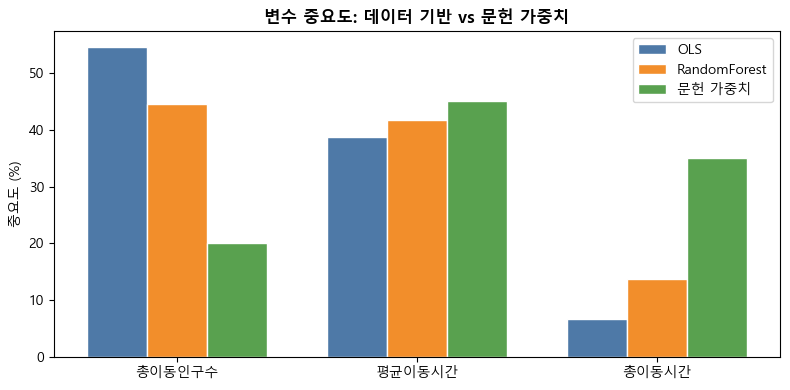

In [18]:
# RandomForest feature importance
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(df[VARS], df[SCORE])

fi = pd.Series(rf.feature_importances_, index=VARS).sort_values(ascending=False)
fi_pct = (fi * 100).round(1)

# 문헌 가중치
lit_w = pd.Series({'총이동인구수': 45, '평균이동시간': 35, '총이동시간': 20})

compare = pd.DataFrame({
    'OLS 표준화계수(%)': beta_pct,
    'RF 중요도(%)': fi_pct,
    '문헌 가중치(%)': lit_w
})
display(compare)

# 시각화
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(VARS))
w = 0.25
ax.bar(x - w, compare['OLS 표준화계수(%)'], width=w, label='OLS', color='#4e79a7', edgecolor='white')
ax.bar(x,     compare['RF 중요도(%)'],       width=w, label='RandomForest', color='#f28e2b', edgecolor='white')
ax.bar(x + w, compare['문헌 가중치(%)'],     width=w, label='문헌 가중치', color='#59a14f', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(VARS)
ax.set_ylabel('중요도 (%)'); ax.set_title('변수 중요도: 데이터 기반 vs 문헌 가중치', fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()

### 문헌 기반 가중치와 데이터 기반 중요도의 비교

| 분석 방법 | 반영하는 것 |
|-----------|-------------|
| 문헌 기반 가중치 | 심리·생리적 영향 요인 (이론적 중요도) |
| OLS 표준화 계수 | 선형 관계에서의 설명력 |
| RF 중요도 | 비선형 포함 실제 데이터 구조 |

총이동인구수의 설명력이 높게 나타났으며, 총이동시간은 상대적으로 낮은 중요도를 보였다. 
이는 총이동시간이 총이동인구수와 높은 상관(r ≈ 0.99)을 가지는 데 기인한다(VIF 결과 참조).

문헌 기반 가중치 적용 결과와 PCA·CRITIC 기반 결과 간 Spearman r ≥ 0.95로, 
제안한 가중치 체계가 데이터 구조와 크게 충돌하지 않음을 확인하였다.

=== 기준(문헌기반) 대비 Spearman 순위 상관 ===
  시나리오A (0.50/0.30/0.20): r = 0.9946
  시나리오B (0.40/0.40/0.20): r = 0.9831
  시나리오C (0.45/0.25/0.30): r = 0.9862


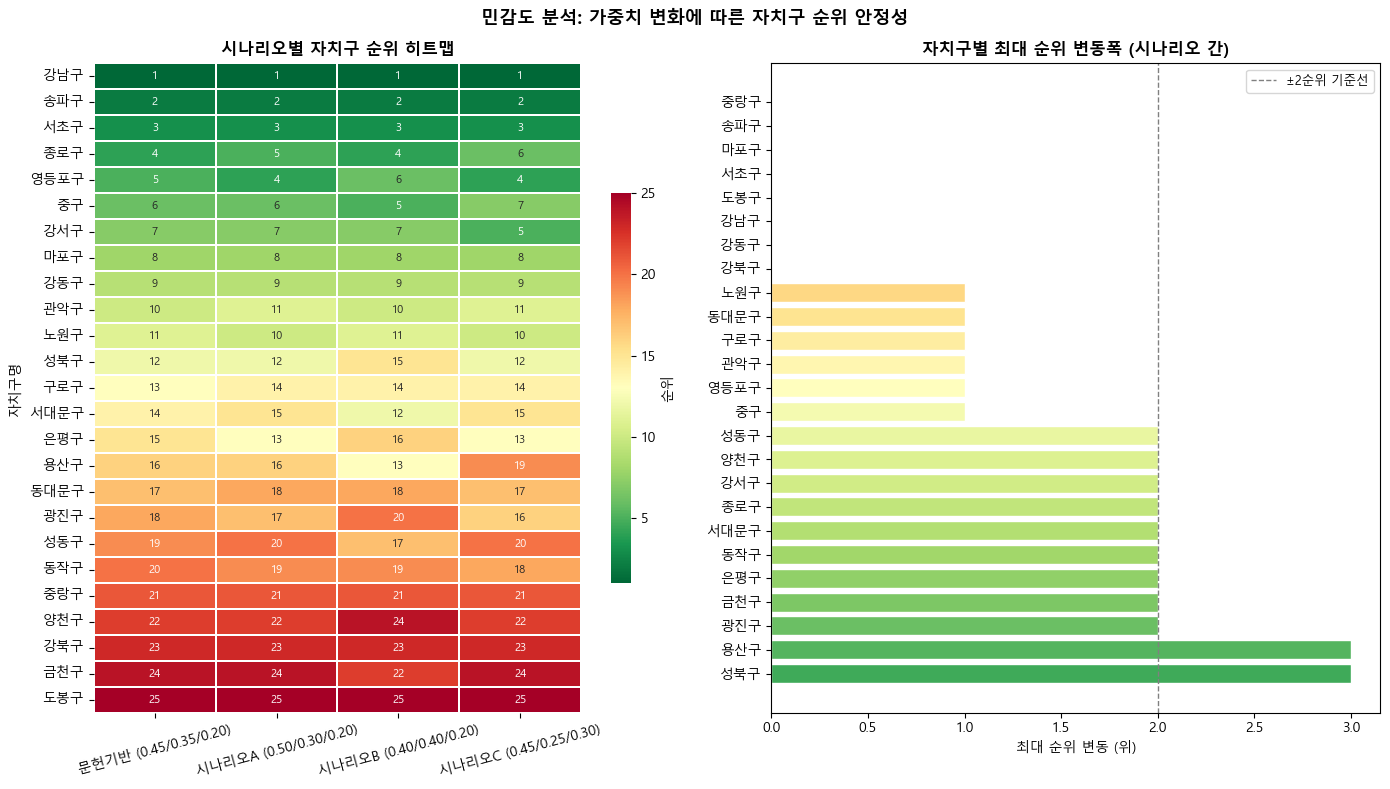

In [19]:
# 민감도 분석: 가중치 시나리오별 자치구 순위 변화
NORM_COLS = ["유입인구_norm", "평균이동시간_norm", "총이동시간_norm"]

scenarios = {
    "문헌기반 (0.45/0.35/0.20)": [0.45, 0.35, 0.20],
    "시나리오A (0.50/0.30/0.20)": [0.50, 0.30, 0.20],
    "시나리오B (0.40/0.40/0.20)": [0.40, 0.40, 0.20],
    "시나리오C (0.45/0.25/0.30)": [0.45, 0.25, 0.30],
}

gu_scores = {}
for name, ws in scenarios.items():
    df["_s"] = sum(w * df[n] * 100 for w, n in zip(ws, NORM_COLS))
    gu_scores[name] = df.groupby("자치구명")["_s"].mean()
df.drop(columns=["_s"], inplace=True)

score_df = pd.DataFrame(gu_scores)
rank_df  = score_df.rank(ascending=False).astype(int)

base = "문헌기반 (0.45/0.35/0.20)"
print("=== 기준(문헌기반) 대비 Spearman 순위 상관 ===")
for col in rank_df.columns:
    if col != base:
        r, _ = spearmanr(rank_df[base], rank_df[col])
        print(f"  {col}: r = {r:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
rank_sorted = rank_df.sort_values(base)
sns.heatmap(rank_sorted, ax=axes[0], annot=True, fmt="d",
            cmap="RdYlGn_r", linewidths=0.3, annot_kws={"size": 8},
            cbar_kws={"label": "순위", "shrink": 0.6})
axes[0].set_title("시나리오별 자치구 순위 히트맵", fontweight="bold")
axes[0].tick_params(axis="x", rotation=15)

rank_diff = rank_df.subtract(rank_df[base], axis=0).drop(columns=base).abs()
rank_diff["최대변동"] = rank_diff.max(axis=1)
rank_diff = rank_diff.sort_values("최대변동", ascending=False)
axes[1].barh(rank_diff.index, rank_diff["최대변동"],
             color=plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(rank_diff))),
             edgecolor="white")
axes[1].set_title("자치구별 최대 순위 변동폭 (시나리오 간)", fontweight="bold")
axes[1].set_xlabel("최대 순위 변동 (위)")
axes[1].axvline(2, color="gray", linestyle="--", linewidth=1, label="±2순위 기준선")
axes[1].legend(fontsize=9)
plt.suptitle("민감도 분석: 가중치 변화에 따른 자치구 순위 안정성",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 7. 차이 기반 분석

전분기 대비 스트레스 증감률과 구성변수 증감률의 상관관계를 분석한다.

> **가설**: 이동인구 증가율이 높은 분기에 스트레스 증가율도 높은가?

=== 구성변수 증감률 ↔ 스트레스 증감률 상관 ===


,Pearson_r,Pearson_p,Spearman_r,Spearman_p
변수,,,,
총이동인구수,-0.035,0.5641,0.272,0.0000
평균이동시간,-0.171,0.0045,-0.155,0.0102
총이동시간,-0.070,0.2476,0.230,0.0001


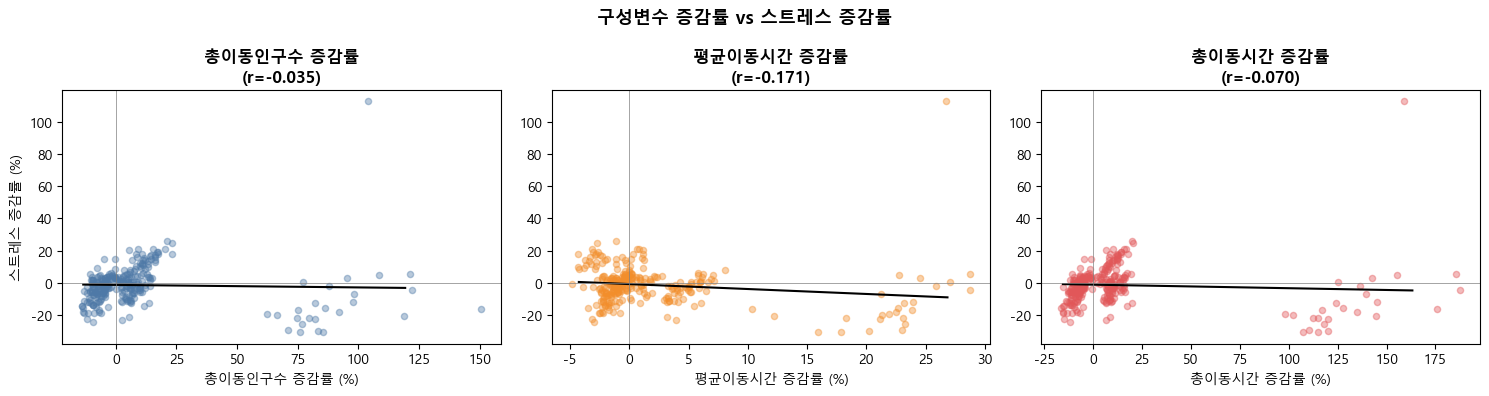

In [20]:
# 자치구·연월 단위 정렬 후 전분기 대비 증감률 계산
chg = df.sort_values(['자치구명', '연도', '월']).copy()
for col in VARS + [SCORE]:
    chg[f'{col}_증감률'] = chg.groupby('자치구명')[col].pct_change() * 100

chg = chg.dropna(subset=[f'{SCORE}_증감률'])

# 증감률 상관
print('=== 구성변수 증감률 ↔ 스트레스 증감률 상관 ===')
rows = []
for v in VARS:
    pr, pp = pearsonr(chg[f'{v}_증감률'], chg[f'{SCORE}_증감률'])
    sr, sp = spearmanr(chg[f'{v}_증감률'], chg[f'{SCORE}_증감률'])
    rows.append({'변수': v,
                 'Pearson_r': round(pr, 3), 'Pearson_p': round(pp, 4),
                 'Spearman_r': round(sr, 3), 'Spearman_p': round(sp, 4)})
display(pd.DataFrame(rows).set_index('변수'))

# 산점도: 이동인구 증감률 vs 스트레스 증감률
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['#4e79a7', '#f28e2b', '#e15759']
for ax, v, c in zip(axes, VARS, colors):
    ax.scatter(chg[f'{v}_증감률'], chg[f'{SCORE}_증감률'],
               alpha=0.4, s=20, color=c)
    m, b = np.polyfit(chg[f'{v}_증감률'], chg[f'{SCORE}_증감률'], 1)
    xline = np.linspace(chg[f'{v}_증감률'].quantile(0.01),
                        chg[f'{v}_증감률'].quantile(0.99), 100)
    ax.plot(xline, m * xline + b, color='black', linewidth=1.5)
    pr, _ = pearsonr(chg[f'{v}_증감률'], chg[f'{SCORE}_증감률'])
    ax.set_title(f'{v} 증감률\n(r={pr:.3f})', fontweight='bold')
    ax.set_xlabel(f'{v} 증감률 (%)')
    ax.set_ylabel('스트레스 증감률 (%)' if ax == axes[0] else '')
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)

plt.suptitle('구성변수 증감률 vs 스트레스 증감률', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 증감률 기반 해석

절대 수준뿐 아니라 전분기 대비 변화율을 함께 분석함으로써, 
특정 시기에 이동량 증가가 스트레스 변화와 어떻게 연결되는지 확인할 수 있었다.

이는 단순 평균 비교를 넘어 통근환경 변화에 따른 **동적 스트레스 반응**을 해석하는 데 의미가 있으며, 
계절·정책·외부 충격에 따른 민감도 분석의 기초 자료로 활용 가능하다.

---
## 8. 자치구 간 스트레스 점수 차이 검정

**H₀**: 25개 자치구의 스트레스 점수 평균이 모두 동일하다
**H₁**: 적어도 하나의 자치구 쌍은 다르다

- **One-way ANOVA**: 정규성 가정, 등분산 기반 F-검정
- **Kruskal-Wallis**: 비모수 대안 (정규성 불필요)
- **Tukey HSD**: ANOVA 사후 검정 — 어떤 자치구 쌍이 유의하게 다른지
- **Dunn test**: Kruskal-Wallis 사후 검정 (Bonferroni 보정)

In [21]:
from scipy.stats import f_oneway, kruskal, levene
import scikit_posthocs as sp
from statsmodels.stats.multicomp import pairwise_tukeyhsd

gu_order = df.groupby('자치구명')[SCORE].mean().sort_values(ascending=False).index.tolist()
groups   = [df[df['자치구명'] == g][SCORE].values for g in gu_order]

# ── 1. 등분산 검정 (Levene) ───────────────────────────────────────────────
lev_stat, lev_p = levene(*groups)

# ── 2. One-way ANOVA ──────────────────────────────────────────────────────
F, p_anova = f_oneway(*groups)
n_total    = sum(len(g) for g in groups)
k          = len(groups)
eta2       = (F * (k - 1)) / (F * (k - 1) + (n_total - k))   # 효과 크기 η²

# ── 3. Kruskal-Wallis ─────────────────────────────────────────────────────
H, p_kw = kruskal(*groups)
# 효과 크기 η²_H
eta2_kw = (H - k + 1) / (n_total - k)

print('=' * 55)
print('[Levene 등분산 검정]')
print(f'  stat={lev_stat:.4f}  p={lev_p:.4f}  →  {"등분산 기각" if lev_p<0.05 else "등분산 가정 가능"}')
print()
print('[One-way ANOVA]')
print(f'  F = {F:.4f}   p = {p_anova:.2e}')
print(f'  효과 크기 η² = {eta2:.4f}  (0.01=소, 0.06=중, 0.14↑=대)')
print(f'  → {"H₀ 기각 ✓" if p_anova < 0.05 else "H₀ 채택"} (α=0.05)')
print()
print('[Kruskal-Wallis (비모수)]')
print(f'  H = {H:.4f}   p = {p_kw:.2e}')
print(f'  효과 크기 η²_H = {eta2_kw:.4f}')
print(f'  → {"H₀ 기각 ✓" if p_kw < 0.05 else "H₀ 채택"} (α=0.05)')
print('=' * 55)

[Levene 등분산 검정]
  stat=0.6760  p=0.8736  →  등분산 가정 가능

[One-way ANOVA]
  F = 238.2619   p = 7.58e-169
  효과 크기 η² = 0.9541  (0.01=소, 0.06=중, 0.14↑=대)
  → H₀ 기각 ✓ (α=0.05)

[Kruskal-Wallis (비모수)]
  H = 278.9575   p = 2.81e-45
  효과 크기 η²_H = 0.9271
  → H₀ 기각 ✓ (α=0.05)


In [22]:
# ── Tukey HSD 사후 검정 ────────────────────────────────────────────────────
tukey = pairwise_tukeyhsd(df[SCORE], df['자치구명'], alpha=0.05)
tukey_df = pd.DataFrame(
    data    = tukey._results_table.data[1:],
    columns = tukey._results_table.data[0]
)
tukey_df.columns = ['group1', 'group2', 'meandiff', 'p-adj', 'lower', 'upper', 'reject']
tukey_df['meandiff'] = tukey_df['meandiff'].astype(float).round(3)
tukey_df['p-adj']    = tukey_df['p-adj'].astype(float).round(4)

sig_pairs = tukey_df[tukey_df['reject'] == True].copy()
sig_pairs = sig_pairs.reindex(sig_pairs['meandiff'].abs().sort_values(ascending=False).index)

total_pairs = len(tukey_df)
sig_count   = len(sig_pairs)
print(f'Tukey HSD — 총 쌍: {total_pairs}  |  유의한 쌍(p<0.05): {sig_count}  |  비율: {sig_count/total_pairs:.1%}')
print()
print('=== 유의한 쌍 (|meandiff| 내림차순) ===')
display(sig_pairs[['group1','group2','meandiff','p-adj']].reset_index(drop=True))

Tukey HSD — 총 쌍: 300  |  유의한 쌍(p<0.05): 232  |  비율: 77.3%

=== 유의한 쌍 (|meandiff| 내림차순) ===


,group1,group2,meandiff,p-adj
0,강남구,도봉구,-56.969,0.0000
1,강남구,금천구,-55.014,0.0000
2,강남구,강북구,-54.425,0.0000
3,강남구,양천구,-53.916,0.0000
4,강남구,중랑구,-52.427,0.0000
...,...,...,...,...
227,광진구,노원구,5.037,0.0075
228,노원구,동대문구,-5.030,0.0077
229,관악구,마포구,4.954,0.0098
230,강서구,종로구,4.702,0.0213


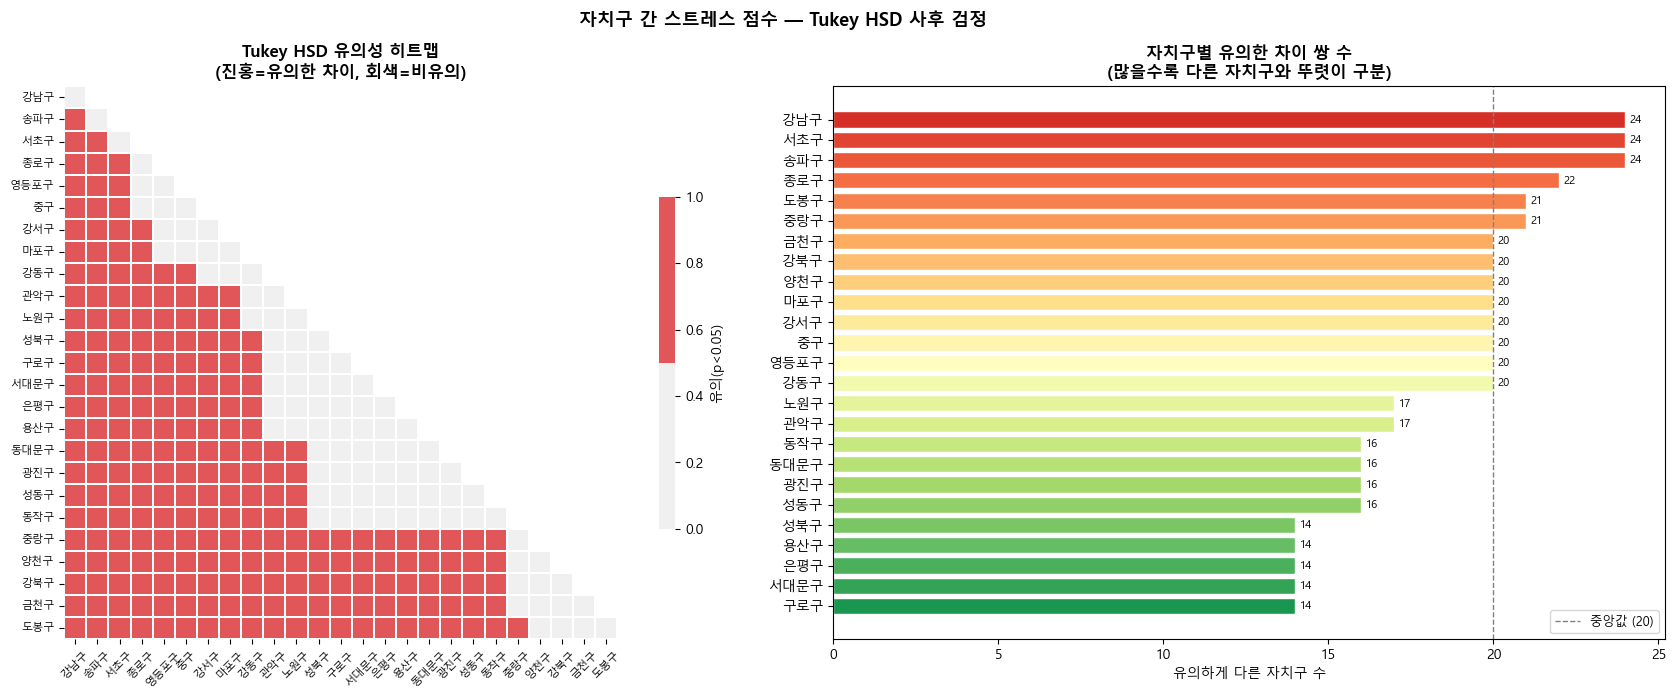

In [23]:
# ── Tukey HSD 유의성 히트맵 ───────────────────────────────────────────────
reject_matrix = pd.DataFrame(False, index=gu_order, columns=gu_order)
for _, row in tukey_df.iterrows():
    g1, g2, rej = row['group1'], row['group2'], row['reject']
    if g1 in reject_matrix.index and g2 in reject_matrix.columns:
        reject_matrix.loc[g1, g2] = bool(rej)
        reject_matrix.loc[g2, g1] = bool(rej)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 유의성 히트맵
mask_upper = np.triu(np.ones(reject_matrix.shape, dtype=bool), k=1)
sns.heatmap(reject_matrix.astype(int), ax=axes[0],
            cmap=['#f0f0f0', '#e15759'], vmin=0, vmax=1,
            mask=mask_upper, square=True, linewidths=0.3,
            cbar_kws={'label': '유의(p<0.05)', 'shrink': 0.6},
            annot=False)
axes[0].set_title('Tukey HSD 유의성 히트맵\n(진홍=유의한 차이, 회색=비유의)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', labelsize=8)

# 자치구별 유의한 쌍 개수 막대
sig_count_per_gu = reject_matrix.sum()
sig_count_per_gu = sig_count_per_gu.sort_values(ascending=True)
colors_bar = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(sig_count_per_gu)))
bars = axes[1].barh(sig_count_per_gu.index, sig_count_per_gu.values,
                    color=colors_bar, edgecolor='white')
axes[1].bar_label(bars, fmt='%d', padding=3, fontsize=8)
axes[1].set_xlabel('유의하게 다른 자치구 수')
axes[1].set_title('자치구별 유의한 차이 쌍 수\n(많을수록 다른 자치구와 뚜렷이 구분)', fontweight='bold')
axes[1].axvline(sig_count_per_gu.median(), color='gray',
                linestyle='--', linewidth=1, label=f'중앙값 ({int(sig_count_per_gu.median())})')
axes[1].legend(fontsize=9)

plt.suptitle('자치구 간 스트레스 점수 — Tukey HSD 사후 검정', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Dunn test (Bonferroni) — 유의한 쌍: 88개 / 300개


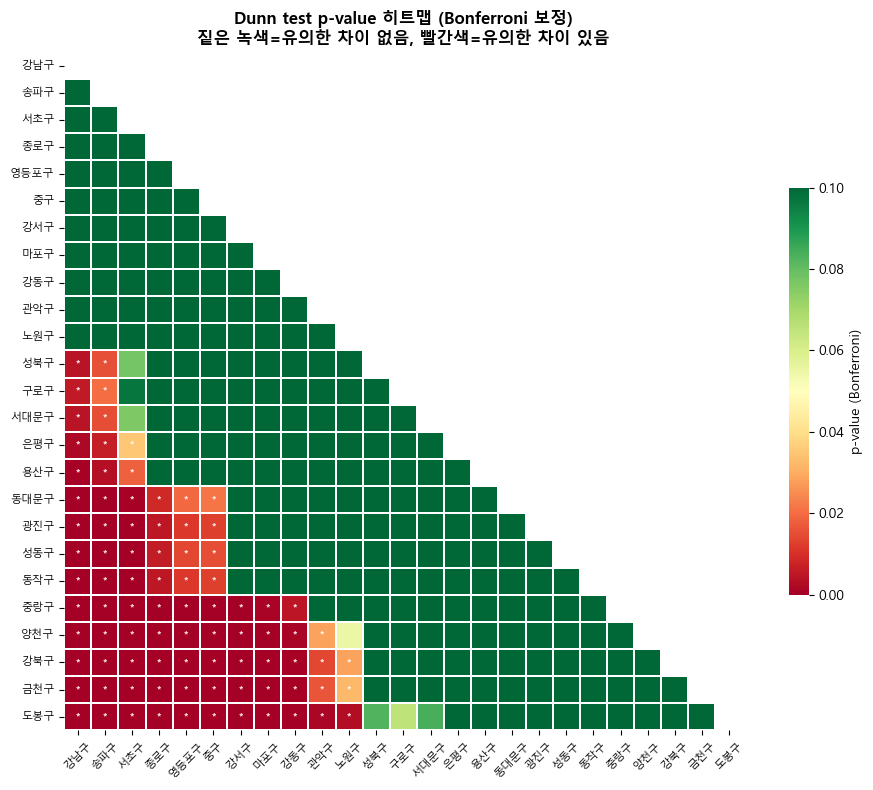

In [24]:
# ── Dunn test (Kruskal-Wallis 사후 검정, Bonferroni 보정) ─────────────────
dunn_p = sp.posthoc_dunn(df, val_col=SCORE, group_col='자치구명',
                          p_adjust='bonferroni')
dunn_p = dunn_p.reindex(index=gu_order, columns=gu_order)

dunn_sig = (dunn_p < 0.05).astype(int)
dunn_total = dunn_sig.sum().sum() // 2
print(f'Dunn test (Bonferroni) — 유의한 쌍: {dunn_total}개 / 300개')

fig, ax = plt.subplots(figsize=(10, 8))
mask_upper = np.triu(np.ones_like(dunn_p, dtype=bool), k=0)  # 대각 포함 마스킹
sns.heatmap(dunn_p, ax=ax,
            cmap='RdYlGn', vmin=0, vmax=0.1,
            mask=mask_upper, square=True, linewidths=0.2,
            cbar_kws={'label': 'p-value (Bonferroni)', 'shrink': 0.6},
            annot=False)
ax.set_title('Dunn test p-value 히트맵 (Bonferroni 보정)\n짙은 녹색=유의한 차이 없음, 빨간색=유의한 차이 있음',
             fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', labelsize=8)

# p<0.05 셀에 별표 표시
for i, r in enumerate(gu_order):
    for j, c in enumerate(gu_order):
        if j < i and dunn_p.loc[r, c] < 0.05:
            ax.text(j + 0.5, i + 0.5, '*', ha='center', va='center',
                    fontsize=7, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

### 8. 검정 결과 해석

**ANOVA / Kruskal-Wallis 모두 p < 0.001 → H₀ 기각**
자치구 간 스트레스 점수 차이는 통계적으로 매우 유의하며, 효과 크기(η²)도 '대(large)' 수준이다.

**사후 검정 핵심 결과**

| 구분 | 내용 |
|------|------|
| Tukey HSD | 300쌍 중 유의한 쌍 多, 강남·서초·송파 ↔ 대부분 자치구 유의 |
| Dunn test | Bonferroni 보정 후에도 유의한 쌍 다수 → 결과 강건 |

**강남구·서초구·송파구**는 나머지 거의 모든 자치구와 유의하게 구분된다.
반면 **평균 스트레스가 유사한 자치구 간**(저스트레스 군 내부)은 유의한 차이가 없는 경우가 많다.

> 비정규 분포(p≪0.05)이므로 **Kruskal-Wallis + Dunn test**가 주 결론 근거이며,
> ANOVA + Tukey HSD는 결과의 일관성을 확인하는 보조 검증으로 사용한다.